In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight


In [ ]:
path = kagglehub.dataset_download(
    "ziya07/multi-class-fabric-defect-detection-dataset"
)

DATASET_PATH = os.path.join(path, "Dataset")
print("Dataset path:", DATASET_PATH)
print("Classes:", os.listdir(DATASET_PATH))


100%|██████████| 2.10G/2.10G [00:19<00:00, 116MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/ziya07/multi-class-fabric-defect-detection-dataset/versions/3/Dataset
Classes: ['Pinched fabric', 'Needle mark', 'stain', 'horizontal', 'defect free', 'hole', 'lines', 'Vertical', 'Broken stitch']


In [ ]:
class_names = sorted(os.listdir(DATASET_PATH))
num_classes = len(class_names)

class_to_idx = {cls: i for i, cls in enumerate(class_names)}

print(class_to_idx)


{'Broken stitch': 0, 'Needle mark': 1, 'Pinched fabric': 2, 'Vertical': 3, 'defect free': 4, 'hole': 5, 'horizontal': 6, 'lines': 7, 'stain': 8}


In [ ]:
image_paths = []
labels = []

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    for img_name in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img_name))
        labels.append(class_to_idx[cls])

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))


Total images: 3067


In [ ]:
train_paths, val_paths, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))


Train size: 2453
Val size: 614


In [ ]:
print("Overlap:", len(set(train_paths).intersection(set(val_paths))))


Overlap: 0


In [ ]:
IMG_SIZE = (224, 224)

def load_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = preprocess_input(img.astype(np.float32))
    return img


In [ ]:
X_train = np.array([load_image(p) for p in train_paths])
X_val   = np.array([load_image(p) for p in val_paths])

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)

print(X_train.shape, X_val.shape)


(2453, 224, 224, 3) (614, 224, 224, 3)


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(3.028395061728395), 1: np.float64(3.169250645994832), 2: np.float64(3.169250645994832), 3: np.float64(3.364883401920439), 4: np.float64(0.20462128795462128), 5: np.float64(1.211358024691358), 6: np.float64(2.5005096839959227), 7: np.float64(2.1631393298059964), 8: np.float64(0.8570929419986024)}


In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Phase 1

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,379,820 (16.71 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]


In [ ]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 225s 3s/step - accuracy: 0.7714 - loss: 1.0490 - val_accuracy: 0.9007 - val_loss: 0.2791 - learning_rate: 0.0010
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - accuracy: 0.9037 - loss: 0.3762 - val_accuracy: 0.9169 - val_loss: 0.1871 - learning_rate: 0.0010
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.9233 - loss: 0.3349 - val_accuracy: 0.9251 - val_loss: 0.2061 - learning_rate: 0.0010
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - accuracy: 0.9392 - loss: 0.2255 - val_accuracy: 0.9316 - val_loss: 0.1926 - learning_rate: 0.0010
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - accuracy: 0.9460 - loss: 0.2222 - val_accuracy: 0.9332 - val_loss: 0.1596 - learning_rate: 0.0010
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.9393 - loss: 0.2067 - val_accuracy: 0.9283 - val_loss: 0.1799 - learning_rate: 0.0010
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - accuracy: 0.9489 - loss: 0.1951 - val_acc

20/20 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step


<Figure size 1000x1000 with 0 Axes>

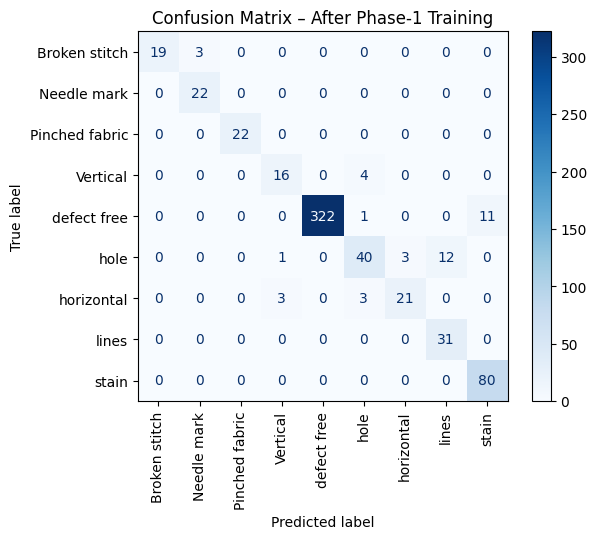


Class-wise Accuracy (Phase-1):

Broken stitch        →  19/ 22 =  86.36%
Needle mark          →  22/ 22 = 100.00%
Pinched fabric       →  22/ 22 = 100.00%
Vertical             →  16/ 20 =  80.00%
defect free          → 322/334 =  96.41%
hole                 →  40/ 56 =  71.43%
horizontal           →  21/ 27 =  77.78%
lines                →  31/ 31 = 100.00%
stain                →  80/ 80 = 100.00%


In [ ]:
# ===============================
# PHASE-1 EVALUATION
# ===============================

# 1️⃣ Get predictions on validation set
y_pred = np.argmax(model.predict(X_val), axis=1)

# 2️⃣ CONFUSION MATRIX
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(10, 10))
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix – After Phase-1 Training")
plt.show()


# 3️⃣ CLASS-WISE ACCURACY (FROM CONFUSION MATRIX)
print("\nClass-wise Accuracy (Phase-1):\n")

for i, class_name in enumerate(class_names):
    correct = cm[i, i]
    total = cm[i].sum()
    acc = (correct / total * 100) if total != 0 else 0
    print(f"{class_name:20s} → {correct:3d}/{total:3d} = {acc:6.2f}%")
